In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:

!pip install wfdb -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.7 MB/s eta 0:00:00


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import wfdb
import pywt
from scipy.signal import butter, filtfilt
from PIL import Image
from collections import Counter
import os, warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")

All libraries loaded!


In [6]:
DATA_DIR = '/kaggle/input/datasets/sangatichapla/mit-ecg-raw/mit-bih-arrhythmia-database-1.0.0/mit-bih-arrhythmia-database-1.0.0'  
SAVE_DIR = '/kaggle/working/cwt_output'
os.makedirs(SAVE_DIR, exist_ok=True)

In [7]:
RECORDS = [
    '100','101','102','103','104','105','106','107','108','109',
    '111','112','113','114','115','116','117','118','119','121',
    '122','123','124','200','201','202','203','205','207','208',
    '209','210','212','213','214','215','217','219','220','221',
    '222','223','228','230','231','232','233','234'
]

BEAT_CLASSES = {'N':0, 'V':1, 'A':2, '/':3, 'F':4}
CLASS_NAMES  = ['Normal(N)', 'PVC(V)', 'APB(A)', 'Paced(/)', 'Fusion(F)']
CLASS_COLORS = ['#2196F3', '#F44336', '#4CAF50', '#9C27B0', '#FF9800']

FS         = 360     # sampling rate Hz
WIN_BEFORE = 90      # samples before R-peak
WIN_AFTER  = 180     # samples after R-peak
BEAT_LEN   = WIN_BEFORE + WIN_AFTER   # 270 samples

CWT_SCALES  = np.arange(1, 65)   # 64 frequency scales
IMG_SIZE    = 64                  # scalogram image size

print(f"Beat length : {BEAT_LEN} samples = {BEAT_LEN/FS*1000:.0f} ms")
print(f"Classes     : {CLASS_NAMES}")

Beat length : 270 samples = 750 ms
Classes     : ['Normal(N)', 'PVC(V)', 'APB(A)', 'Paced(/)', 'Fusion(F)']


In [8]:
path   = os.path.join(DATA_DIR, '100')
record = wfdb.rdrecord(path)
ann    = wfdb.rdann(path, 'atr')

signal  = record.p_signal[:, 0]   # Lead I
r_peaks = ann.sample
symbols = ann.symbol

print(f"Signal length : {len(signal):,} samples = {len(signal)/FS/60:.1f} min")
print(f"Total beats   : {len(r_peaks)}")
print(f"\nAll beat types in record 100:")
for sym, cnt in Counter(symbols).most_common():
    tag = '<-- we use this' if sym in BEAT_CLASSES else ''
    print(f"  '{sym}' : {cnt}  {tag}")

Signal length : 650,000 samples = 30.1 min
Total beats   : 2274

All beat types in record 100:
  'N' : 2239  <-- we use this
  'A' : 33  <-- we use this
  '+' : 1  
  'V' : 1  <-- we use this


In [9]:
def bandpass_filter(signal):
    # Remove noise below 0.5Hz and above 45Hz
    nyq  = 0.5 * FS
    b, a = butter(4, [0.5/nyq, 45/nyq], btype='band')
    return filtfilt(b, a, signal)

def segment_beats(signal, r_peaks, symbols):
    # Cut each beat around its R-peak
    beats, labels = [], []
    for peak, sym in zip(r_peaks, symbols):
        if sym not in BEAT_CLASSES:
            continue
        start = peak - WIN_BEFORE
        end   = peak + WIN_AFTER
        if start < 0 or end >= len(signal):
            continue
        beats.append(signal[start:end])
        labels.append(BEAT_CLASSES[sym])
    return np.array(beats), np.array(labels)

def zscore(beat):
    # Normalize each beat to mean=0, std=1
    return (beat - beat.mean()) / (beat.std() + 1e-8)

print("Functions ready")

Functions ready


In [10]:
# # Show 5 seconds of raw signal with beat labels marked
# start = 0 * FS
# end   = 5 * FS
# t     = np.arange(start, end) / FS

# peaks_in_win = r_peaks[(r_peaks >= start) & (r_peaks < end)]
# syms_in_win  = [symbols[i] for i, p in enumerate(r_peaks)
#                 if start <= p < end]

# fig, ax = plt.subplots(figsize=(16, 4))
# ax.plot(t, raw_signal[start:end], color='#455A64', linewidth=0.8, label='Raw ECG')

# for peak, sym in zip(peaks_in_win, syms_in_win):
#     if sym not in BEAT_CLASSES:
#         continue
#     c = CLASS_COLORS[BEAT_CLASSES[sym]]
#     ax.axvline(peak/FS, color=c, alpha=0.35, linewidth=1)
#     ax.annotate(sym, xy=(peak/FS, raw_signal[peak]),
#                 xytext=(0, 12), textcoords='offset points',
#                 fontsize=9, color=c, ha='center', fontweight='bold')

# ax.set_xlabel('Time (s)', fontsize=11)
# ax.set_ylabel('Amplitude (mV)', fontsize=11)
# ax.set_title('Raw MIT-BIH ECG — Record 100 (first 5 seconds)\nColored labels = beat class',
#              fontsize=12, fontweight='bold')
# ax.legend(); ax.grid(alpha=0.3)
# plt.tight_layout(); plt.show()

In [11]:
def beat_to_scalogram(beat):
    """
    1D beat (270 samples) → 2D image (3, 64, 64)

    Steps:
      1. CWT  : slide Morlet wavelet → (64 scales x 270 time points)
      2. Power: take |coef|^2        → real values, boosts differences
      3. Norm : scale to [0, 1]
      4. Resize to 64x64
      5. Stack 3 channels            → ResNet18 expects 3-channel input
    """
    coef, _    = pywt.cwt(beat, CWT_SCALES, 'morl')
    power      = np.abs(coef) ** 2
    power      = (power - power.min()) / (power.max() - power.min() + 1e-8)
    img        = Image.fromarray((power * 255).astype(np.uint8))
    img        = img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    arr        = np.array(img, dtype=np.float32) / 255.0
    return np.stack([arr, arr, arr], axis=0)   # (3, 64, 64)

# Quick test
test = beat_to_scalogram(np.random.randn(BEAT_LEN))
print(f"Input  shape : (270,)")
print(f"Output shape : {test.shape}  → ready for ResNet18")
print(f"Value range  : {test.min():.2f} to {test.max():.2f}")

Input  shape : (270,)
Output shape : (3, 64, 64)  → ready for ResNet18
Value range  : 0.00 to 0.55


Beats found : 2271
Class counts: Counter({0: 2237, 2: 33, 1: 1})


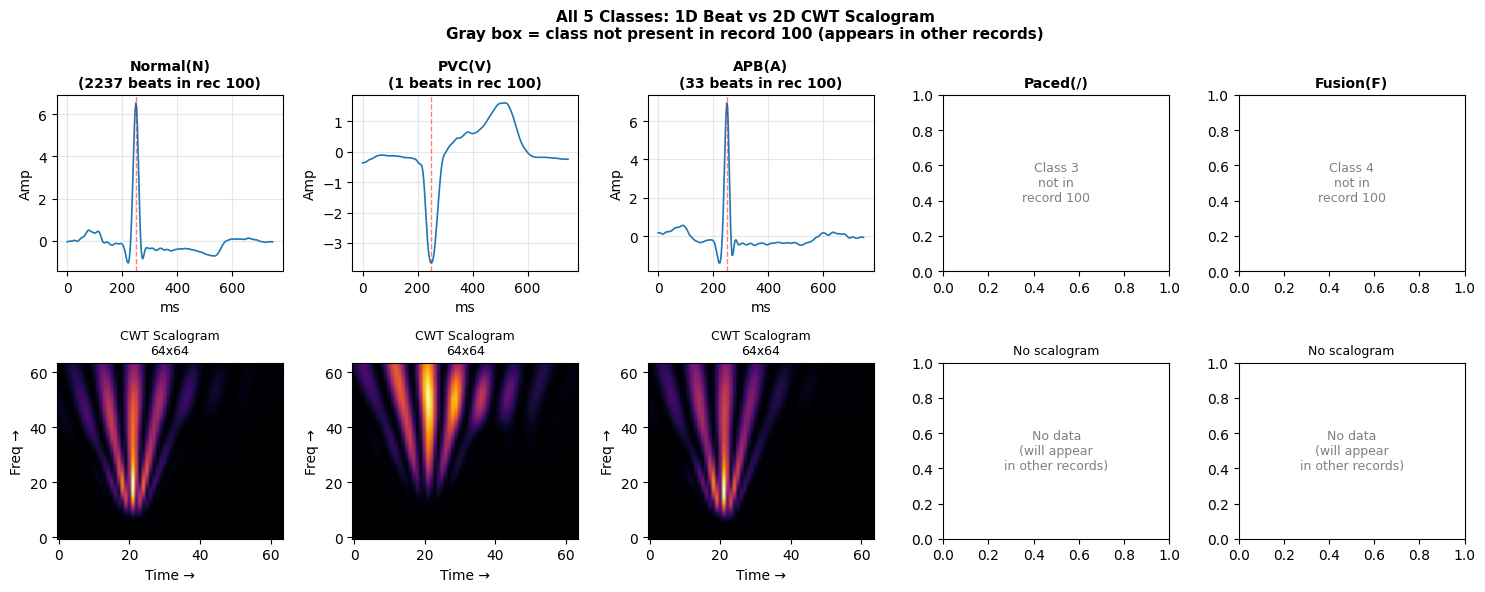


Note: Paced(/) and Fusion(F) are rare classes.
They appear in records like 102, 104, 217 (paced) and 201, 203 (fusion)
All 5 classes will be fully captured when processing all 48 records


In [12]:
# Load & process record 100 first
sig_filtered        = bandpass_filter(record.p_signal[:, 0])
beats_raw, labels   = segment_beats(sig_filtered, r_peaks, symbols)
beats_norm          = np.array([zscore(b) for b in beats_raw])

print(f"Beats found : {len(beats_norm)}")
print(f"Class counts: {Counter(labels.tolist())}")

# Show scalogram for each of the 5 classes
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
t = np.arange(BEAT_LEN) / FS * 1000   # time in ms

for cls in range(5):
    idx = np.where(labels == cls)[0]

    ax_top = axes[0, cls]
    ax_bot = axes[1, cls]

    if len(idx) == 0:
        ax_top.text(0.5, 0.5, f'Class {cls}\nnot in\nrecord 100',
                    ha='center', va='center', transform=ax_top.transAxes,
                    fontsize=9, color='gray')
        ax_bot.text(0.5, 0.5, 'No data\n(will appear\nin other records)',
                    ha='center', va='center', transform=ax_bot.transAxes,
                    fontsize=9, color='gray')
        ax_top.set_title(CLASS_NAMES[cls], fontweight='bold', fontsize=10)
        ax_bot.set_title('No scalogram', fontsize=9)
        continue

    beat_1d  = beats_norm[idx[0]]
    scalo_2d = beat_to_scalogram(beat_1d)

    # Row 1: raw 1D beat
    ax_top.plot(t, beat_1d, linewidth=1.2)
    ax_top.set_title(f'{CLASS_NAMES[cls]}\n({len(idx)} beats in rec 100)',
                     fontweight='bold', fontsize=10)
    ax_top.set_xlabel('ms'); ax_top.set_ylabel('Amp')
    ax_top.axvline(WIN_BEFORE/FS*1000, color='red', ls='--', lw=1, alpha=0.5)
    ax_top.grid(alpha=0.3)

    # Row 2: 2D scalogram
    ax_bot.imshow(scalo_2d[0], cmap='inferno', aspect='auto', origin='lower')
    ax_bot.set_title(f'CWT Scalogram\n{IMG_SIZE}x{IMG_SIZE}', fontsize=9)
    ax_bot.set_xlabel('Time →')
    ax_bot.set_ylabel('Freq →')

plt.suptitle(
    'All 5 Classes: 1D Beat vs 2D CWT Scalogram\n'
    'Gray box = class not present in record 100 (appears in other records)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

print("\nNote: Paced(/) and Fusion(F) are rare classes.")
print("They appear in records like 102, 104, 217 (paced) and 201, 203 (fusion)")
print("All 5 classes will be fully captured when processing all 48 records")

In [13]:
all_scalograms = []
all_labels     = []

for i, rec_id in enumerate(RECORDS):
    try:
        path   = os.path.join(DATA_DIR, rec_id)
        record = wfdb.rdrecord(path)
        ann    = wfdb.rdann(path, 'atr')
    except Exception as e:
        print(f"  skip {rec_id}: {e}")
        continue

    sig    = bandpass_filter(record.p_signal[:, 0])
    beats, lbls = segment_beats(sig, ann.sample, ann.symbol)

    for beat, lbl in zip(beats, lbls):
        scalo = beat_to_scalogram(zscore(beat))
        all_scalograms.append(scalo)
        all_labels.append(lbl)

    print(f"  [{i+1:02d}/48] record {rec_id} done | total so far: {len(all_labels):,}")

X = np.array(all_scalograms, dtype=np.float32)
y = np.array(all_labels,     dtype=np.int64)

print(f"\nFinal X shape : {X.shape}")
print(f"Final y shape : {y.shape}")
print(f"\nClass counts across ALL 48 records:")
for cls_id, name in enumerate(CLASS_NAMES):
    cnt = (y == cls_id).sum()
    pct = cnt / len(y) * 100
    print(f"  {name:<10}: {cnt:6,}  ({pct:.1f}%)")

np.save(f'{SAVE_DIR}/X_scalograms.npy', X)
np.save(f'{SAVE_DIR}/y_labels.npy',     y)
print(f"\nSaved X_scalograms.npy and y_labels.npy to {SAVE_DIR}")

  [01/48] record 100 done | total so far: 2,271
  [02/48] record 101 done | total so far: 4,133
  [03/48] record 102 done | total so far: 6,263
  [04/48] record 103 done | total so far: 8,346
  [05/48] record 104 done | total so far: 9,889
  [06/48] record 105 done | total so far: 12,456
  [07/48] record 106 done | total so far: 14,483
  [08/48] record 107 done | total so far: 16,620
  [09/48] record 108 done | total so far: 18,381
  [10/48] record 109 done | total so far: 18,421
  [11/48] record 111 done | total so far: 18,422
  [12/48] record 112 done | total so far: 20,960
  [13/48] record 113 done | total so far: 22,748
  [14/48] record 114 done | total so far: 24,625
  [15/48] record 115 done | total so far: 26,577
  [16/48] record 116 done | total so far: 28,988
  [17/48] record 117 done | total so far: 30,522
  [18/48] record 118 done | total so far: 30,634
  [19/48] record 119 done | total so far: 32,621
  [20/48] record 121 done | total so far: 34,483
  [21/48] record 122 done

In [14]:
X_check = np.load(f'{SAVE_DIR}/X_scalograms.npy')
y_check = np.load(f'{SAVE_DIR}/y_labels.npy')

print(f"X loaded : {X_check.shape}  dtype={X_check.dtype}")
print(f"y loaded : {y_check.shape}  dtype={y_check.dtype}")
print(f"X range  : {X_check.min():.3f} to {X_check.max():.3f}")
print(f"\nAll 5 classes confirmed:")
for cls_id, name in enumerate(CLASS_NAMES):
    cnt = (y_check == cls_id).sum()
    print(f"  Class {cls_id} {name:<10}: {cnt:,} samples")



X loaded : (92524, 3, 64, 64)  dtype=float32
y loaded : (92524,)  dtype=int64
X range  : 0.000 to 0.984

All 5 classes confirmed:
  Class 0 Normal(N) : 75,022 samples
  Class 1 PVC(V)    : 7,129 samples
  Class 2 APB(A)    : 2,546 samples
  Class 3 Paced(/)  : 7,025 samples
  Class 4 Fusion(F) : 802 samples


In [20]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

y = np.load('/kaggle/working/cwt_output/y_labels.npy')
print("y loaded:", y.shape)

weights = compute_class_weight('balanced', classes=np.arange(5), y=y)
cw      = dict(enumerate(weights))
print("cw ready:", cw)

import os

SAVE_DIR = '/kaggle/working/cwt_output'
X = np.load(f'{SAVE_DIR}/X_scalograms.npy')

np.save(f'{SAVE_DIR}/class_weights.npy', np.array(list(cw.values())))

print("Done. Files saved:")
for f in os.listdir(SAVE_DIR):
    size = os.path.getsize(f'{SAVE_DIR}/{f}') / 1024**2
    print(f"  {f:<25} {size:.1f} MB")


y loaded: (92524,)
cw ready: {0: np.float64(0.24665831356135534), 1: np.float64(2.5957076728853976), 2: np.float64(7.2681853888452475), 3: np.float64(2.634135231316726), 4: np.float64(23.073316708229427)}
Done. Files saved:
  class_weights.npy         0.0 MB
  y_labels.npy              0.7 MB
  X_scalograms.npy          4337.1 MB


In [21]:
import numpy as np
import os
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

SAVE_DIR = '/kaggle/working/cwt_output'

X = np.load(f'{SAVE_DIR}/X_scalograms.npy')
y = np.load(f'{SAVE_DIR}/y_labels.npy')

# Split
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=42)

# Class weights
weights = compute_class_weight('balanced', classes=np.arange(5), y=y_tr)
cw      = dict(enumerate(weights))

CLASS_NAMES = ['Normal','PVC','APB','Paced','Fusion']

print(f"X_tr  : {X_tr.shape}")
print(f"X_val : {X_val.shape}")
print(f"X_te  : {X_te.shape}")
print(f"cw    : {cw}")

X_tr  : (64766, 3, 64, 64)
X_val : (13879, 3, 64, 64)
X_te  : (13879, 3, 64, 64)
cw    : {0: np.float64(0.24665714557745405), 1: np.float64(2.595831663326653), 2: np.float64(7.268911335578002), 3: np.float64(2.6338348922326147), 4: np.float64(23.089483065953655)}


RNN


In [16]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version : 2.19.0
GPU available      : False


In [22]:
import numpy as np
import os

SAVE_DIR = '/kaggle/working/cwt_output'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save all splits
np.save(f'{SAVE_DIR}/X_tr.npy',  X_tr)
np.save(f'{SAVE_DIR}/X_val.npy', X_val)
np.save(f'{SAVE_DIR}/X_te.npy',  X_te)
np.save(f'{SAVE_DIR}/y_tr.npy',  y_tr)
np.save(f'{SAVE_DIR}/y_val.npy', y_val)
np.save(f'{SAVE_DIR}/y_te.npy',  y_te)
np.save(f'{SAVE_DIR}/class_weights.npy', np.array(list(cw.values())))

print("All files saved:")
for f in os.listdir(SAVE_DIR):
    size = os.path.getsize(f'{SAVE_DIR}/{f}') / 1024**2
    print(f"  {f:<25} {size:.1f} MB")

All files saved:
  X_tr.npy                  3035.9 MB
  class_weights.npy         0.0 MB
  X_val.npy                 650.6 MB
  X_te.npy                  650.6 MB
  y_val.npy                 0.1 MB
  y_labels.npy              0.7 MB
  y_te.npy                  0.1 MB
  y_tr.npy                  0.5 MB
  X_scalograms.npy          4337.1 MB
